# Defining Expressiveness for Graph Classification

We will now implement a GIN model with the concatenation of Sum global poolings as the graph-level readout function on the PROTEINS dataset.

In [1]:
#!pip install torch
import torch
#!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.2.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html

torch.manual_seed(11)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROTEINS dataset comprises 1,113 graphs representing proteins, where **every node is an amino acid$**. An **edge connects two nodes when their distance is lower than 0.6 nanometers**. The goal for this dataset is to **classify each protein as an enzyme**. Enzymes are a particular type of protein that act as catalysts to speed up chemical reactions in a cell. For instance, enzymes called lipases aid in the digestion of food.

In [2]:
#!pip install torch_geometric
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root='.', name='PROTEINS').shuffle()

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-----------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {dataset[0].x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: PROTEINS(1113)
-----------------------
Number of graphs: 1113
Number of nodes: 14
Number of features: 3
Number of classes: 2


/home/pierre/Desktop/epita/maj/ing3/gnn/.venv/lib/python3.12/site-packages/torch_geometric/data/dataset.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  if osp.exists(f

We split the data (graphs) into training, validation, and test sets with an 80/10/10 split respectively.
Subsequently, we convert these splits into mini-batches using the `DataLoader` object with a batch size of 64. This means that each batch will contain up to 64 graphs

In [3]:
from torch_geometric.loader import DataLoader

# Create training, validation, and test sets
train_dataset = dataset[:int(len(dataset)*0.8)]
val_dataset   = dataset[int(len(dataset)*0.8):int(len(dataset)*0.9)]
test_dataset  = dataset[int(len(dataset)*0.9):]

print(f'Training set   = {len(train_dataset)} graphs')
print(f'Validation set = {len(val_dataset)} graphs')
print(f'Test set       = {len(test_dataset)} graphs')

# Create mini-batches
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=True)

print('\nTrain loader:')
for i, batch in enumerate(train_loader):
    print(f' - Batch {i}: {batch}')

print('\nValidation loader:')
for i, batch in enumerate(val_loader):
    print(f' - Batch {i}: {batch}')

print('\nTest loader:')
for i, batch in enumerate(test_loader):
    print(f' - Batch {i}: {batch}')

Training set   = 890 graphs
Validation set = 111 graphs
Test set       = 112 graphs

Train loader:
 - Batch 0: DataBatch(edge_index=[2, 9274], x=[2468, 3], y=[64], batch=[2468], ptr=[65])
 - Batch 1: DataBatch(edge_index=[2, 8972], x=[2366, 3], y=[64], batch=[2366], ptr=[65])
 - Batch 2: DataBatch(edge_index=[2, 8820], x=[2350, 3], y=[64], batch=[2350], ptr=[65])
 - Batch 3: DataBatch(edge_index=[2, 9596], x=[2570, 3], y=[64], batch=[2570], ptr=[65])
 - Batch 4: DataBatch(edge_index=[2, 9108], x=[2490, 3], y=[64], batch=[2490], ptr=[65])
 - Batch 5: DataBatch(edge_index=[2, 10022], x=[2637, 3], y=[64], batch=[2637], ptr=[65])
 - Batch 6: DataBatch(edge_index=[2, 9732], x=[2726, 3], y=[64], batch=[2726], ptr=[65])
 - Batch 7: DataBatch(edge_index=[2, 9316], x=[2533, 3], y=[64], batch=[2533], ptr=[65])
 - Batch 8: DataBatch(edge_index=[2, 7994], x=[2074, 3], y=[64], batch=[2074], ptr=[65])
 - Batch 9: DataBatch(edge_index=[2, 11984], x=[3267, 3], y=[64], batch=[3267], ptr=[65])
 - Batch 

## implementing the GIN
 The first question we have to answer is the composition of our GIN layer. We need an MLP with at least two layers. 
 Following the authors’ guidelines, we can also introduce **batch normalization** to standardize the inputs of each hidden layer, which stabilizes and speeds up training. 
 In summary, our GIN layer has the following composition:
$$Linear \rightarrow BatchNorm \rightarrow ReLU \rightarrow Linear \rightarrow ReLU$$
It can be implemented as follows (we implement first a GCN for comparison aims):

In [4]:
import torch
torch.manual_seed(11)
import torch.nn.functional as F
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.nn import global_mean_pool, global_add_pool


class GCN(torch.nn.Module):
    """GCN"""
    def __init__(self, dim_h):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(dataset.num_node_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = Linear(dim_h, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # Node embeddings 
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)

        # Graph-level readout
        hG = global_mean_pool(h, batch)

        # Classifier
        h = F.dropout(hG, p=0.5, training=self.training)
        h = self.lin(h)
        
        return F.log_softmax(h, dim=1)

class GIN(torch.nn.Module):
    """GIN"""
    def __init__(self, dim_h):
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(Linear(dataset.num_node_features, dim_h),
                       BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.lin1 = Linear(dim_h*3, dim_h*3)
        self.lin2 = Linear(dim_h*3, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # Node embeddings 
        h1 = self.conv1(x, edge_index)
        h2 = self.conv2(h1, edge_index)
        h3 = self.conv3(h2, edge_index)

        # Graph-level readout
        h1 = global_add_pool(h1, batch)
        h2 = global_add_pool(h2, batch)
        h3 = global_add_pool(h3, batch)

        # Concatenate graph embeddings
        h = torch.cat((h1, h2, h3), dim=1)

        # Classifier
        h = self.lin1(h)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)
        
        return F.log_softmax(h, dim=1)

Note that PyTorch Geometric also offers the `GINE` layer, a modified version of the `GIN` layer. It was introduced in 2019 by Hu et al. in “Strategies for Pre-training Graph Neural Networks”. Its major improvement over the previous GIN version is the ability to consider **edge features** during the aggregation process. The PROTEINS dataset does not have edge features, which is why we will implement the classic GIN model instead.

We can now implement a regular training loop with mini-batching for 100 epochs:



In [ ]:
def train(model, loader):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    epochs = 100

    model.train()
    for epoch in range(epochs+1):
        total_loss = 0
        acc = 0
        val_loss = 0
        val_acc = 0

        # Train on batches
        for data in loader:
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_loss += loss / len(loader)
            acc += accuracy(out.argmax(dim=1), data.y) / len(loader)
            loss.backward()
            optimizer.step()

            # Validation
            val_loss, val_acc = test(model, val_loader)

        # Print metrics every 20 epochs
        if(epoch % 10 == 0):
            print(f'Epoch {epoch:>3} | Train Loss: {total_loss:.2f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')
            
    return model

@torch.no_grad()
def test(model, loader):
    criterion = torch.nn.CrossEntropyLoss()
    model.eval()
    loss = 0
    acc = 0

    for data in loader:
        out = model(data.x, data.edge_index, data.batch)
        loss += criterion(out, data.y) / len(loader)
        acc += accuracy(out.argmax(dim=1), data.y) / len(loader)

    return loss, acc

def accuracy(pred_y, y):
    """Calculate accuracy."""
    return ((pred_y == y).sum() / len(y)).item()

gcn = GCN(dim_h=32)
gcn = train(gcn, train_loader)
test_loss, test_acc = test(gcn, test_loader)
print(f'Test Loss: {test_loss:.2f} | Test Acc: {test_acc*100:.2f}%')
print()

gin = GIN(dim_h=32)
gin = train(gin, train_loader)
test_loss, test_acc = test(gin, test_loader)
print(f'Test Loss: {test_loss:.2f} | Test Acc: {test_acc*100:.2f}%')

Epoch   0 | Train Loss: 0.67 | Train Acc: 59.74% | Val Loss: 0.67 | Val Acc: 61.04%
Epoch  10 | Train Loss: 0.66 | Train Acc: 62.03% | Val Loss: 0.65 | Val Acc: 58.41%
Epoch  20 | Train Loss: 0.63 | Train Acc: 69.79% | Val Loss: 0.64 | Val Acc: 65.72%
Epoch  30 | Train Loss: 0.62 | Train Acc: 70.08% | Val Loss: 0.63 | Val Acc: 67.07%
Epoch  40 | Train Loss: 0.61 | Train Acc: 70.25% | Val Loss: 0.62 | Val Acc: 68.92%
Epoch  50 | Train Loss: 0.61 | Train Acc: 70.55% | Val Loss: 0.61 | Val Acc: 69.98%
Epoch  60 | Train Loss: 0.60 | Train Acc: 70.29% | Val Loss: 0.61 | Val Acc: 69.70%
Epoch  70 | Train Loss: 0.60 | Train Acc: 70.75% | Val Loss: 0.60 | Val Acc: 71.54%
Epoch  80 | Train Loss: 0.60 | Train Acc: 71.14% | Val Loss: 0.60 | Val Acc: 71.33%
Epoch  90 | Train Loss: 0.60 | Train Acc: 70.43% | Val Loss: 0.59 | Val Acc: 70.20%
Epoch 100 | Train Loss: 0.60 | Train Acc: 71.30% | Val Loss: 0.59 | Val Acc: 71.61%
Test Loss: 0.66 | Test Acc: 67.71%

Epoch   0 | Train Loss: 0.72 | Train Acc

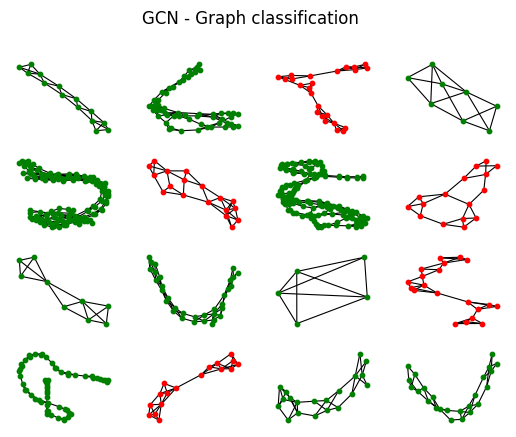

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

fig, ax = plt.subplots(4, 4)
fig.suptitle('GCN - Graph classification')

for i, data in enumerate(dataset[-16:]):
    # Calculate color (green if correct, red otherwise)
    out = gcn(data.x, data.edge_index, data.batch)
    color = "green" if out.argmax(dim=1) == data.y else "red"

    # Plot graph
    ix = np.unravel_index(i, ax.shape)
    ax[ix].axis('off')
    G = to_networkx(dataset[i], to_undirected=True)
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=False,
                    node_size=10,
                    node_color=color,
                    width=0.8,
                    ax=ax[ix]
                    )

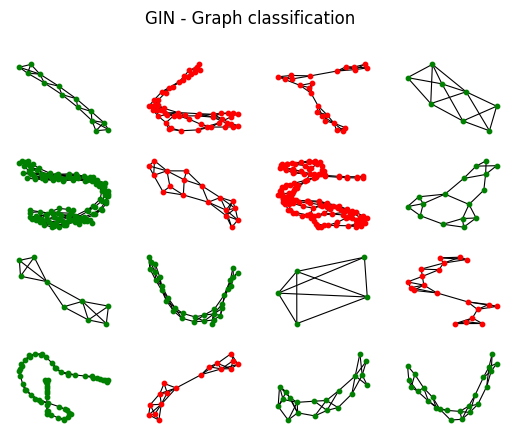

In [7]:
fig, ax = plt.subplots(4, 4)
fig.suptitle('GIN - Graph classification')

for i, data in enumerate(dataset[-16:]):
    # Calculate color (green if correct, red otherwise)
    out = gin(data.x, data.edge_index, data.batch)
    color = "green" if out.argmax(dim=1) == data.y else "red"

    # Plot graph
    ix = np.unravel_index(i, ax.shape)
    ax[ix].axis('off')
    G = to_networkx(dataset[i], to_undirected=True)
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=False,
                    node_size=10,
                    node_color=color,
                    width=0.8,
                    ax=ax[ix]
                    )

Creating ensembles from models that make different mistakes is a common technique in machine learning. We could use different approaches, such as a third model trained on our final classifications. As creating ensembles is not the goal of this lesson,  we will implement a simple model-averaging technique instead:

In [8]:
gcn.eval()
gin.eval()
acc_gcn = 0
acc_gin = 0
acc_ens = 0

for data in test_loader:
    # Get classifications
    out_gcn = gcn(data.x, data.edge_index, data.batch)
    out_gin = gin(data.x, data.edge_index, data.batch)
    out_ens = (out_gcn + out_gin)/2

    # Calculate accuracy scores
    acc_gcn += accuracy(out_gcn.argmax(dim=1), data.y) / len(test_loader)
    acc_gin += accuracy(out_gin.argmax(dim=1), data.y) / len(test_loader)
    acc_ens += accuracy(out_ens.argmax(dim=1), data.y) / len(test_loader)

# Print results
print(f'GCN accuracy:     {acc_gcn*100:.2f}%')
print(f'GIN accuracy:     {acc_gin*100:.2f}%')
print(f'GCN+GIN accuracy: {acc_ens*100:.2f}%')

GCN accuracy:     67.71%
GIN accuracy:     73.70%
GCN+GIN accuracy: 71.09%


Alternatively, we can write the GIN Model in a more concise way.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool, global_max_pool

class GINLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(GINLayer, self).__init__()
        self.conv = GINConv(nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        ))

    def forward(self, x, edge_index):
        x = self.conv(x, edge_index)
        return x

class GINModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(GINModel, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([GINLayer(hidden_dim, hidden_dim) for _ in range(num_layers)])
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.embedding(x))
        for layer in self.layers:
            x = layer(x, edge_index)
            x = F.relu(x)
        x = global_add_pool(x, edge_index)
        x = F.dropout(x, p, training=self.training)
        x = self.fc(x)
        return F.log_softmax(x, dim=-1)

# Example usage:
input_dim = dataset.num_node_features 
hidden_dim = 32
output_dim = dataset.num_classes  
num_layers = 3
p = 0.
print("nb dim input:", input_dim, "nb hidden dim:",hidden_dim, "nb output dim:",output_dim)
model = GINModel(input_dim, hidden_dim, output_dim, num_layers)
print(model)

gin = train(gin, train_loader)
test_loss, test_acc = test(gin, test_loader)
print(f'Test Loss: {test_loss:.2f} | Test Acc: {test_acc*100:.2f}%')

nb dim input: 3 nb hidden dim: 32 nb output dim: 2
GINModel(
  (embedding): Linear(in_features=3, out_features=32, bias=True)
  (layers): ModuleList(
    (0-2): 3 x GINLayer(
      (conv): GINConv(nn=Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): Linear(in_features=32, out_features=32, bias=True)
        (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=32, bias=True)
        (5): ReLU()
        (6): Linear(in_features=32, out_features=32, bias=True)
      ))
    )
  )
  (fc): Linear(in_features=32, out_features=2, bias=True)
)
Epoch   0 | Train Loss: 0.56 | Train Acc: 75.57% | Val Loss: 0.52 | Val Acc: 80.20%
Epoch  10 | Train Loss: 0.49 | Train Acc: 76.92% | Val Loss: 0.53 | Val Acc: 77.58%
Epoch  20 | Train Loss: 0.48 | Train Acc: 77.13% | Val Loss: 0.50 | Val Acc: 82.40%
Epoch  30 | Train Loss: 0.47 | Train Acc: 77.95% | Val Loss: 0.53 | 

### TODO
Through several (at least 3) graph classification datasets (BA2Motif, Proteins, Mutag, etc.)
- Compare GIN against GCN, and GAT
- Compare the different graph pooling strategies on GCN : what do you observe?
- Does GIN always outperform other models?
- What about the cost of learning such models?

In [ ]:
from torch_geometric.nn import GATConv
class GAT(torch.nn.Module):
    """GAT"""
    def __init__(self, dim_h):
        super(GAT, self).__init__()
        self.conv1 = GATConv(dataset.num_node_features, dim_h, heads=8, dropout=0.6)
        self.conv2 = GATConv(dim_h * 8, dim_h, heads=8, concat=False, dropout=0.6)
        self.conv3 = GATConv(dim_h * 8, dim_h, heads=1, concat=False, dropout=0.6)
        self.lin = Linear(dim_h, dataset.num_classes)
        

    def forward(self, x, edge_index, batch):
        # Node embeddings 
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)
        # Graph-level readout
        hG = global_add_pool(h, batch)

        # Classifier
        h = F.dropout(hG, p=0.5, training=self.training)
        h = self.lin(h)
        
        return F.log_softmax(h, dim=1)
class GCN_pool(torch.nn.Module):
    """GCN"""
    def __init__(self, dim_h, pool_method='mean'):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(dataset.num_node_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = Linear(dim_h, dataset.num_classes)
        self.pool_method = pool_method

    def forward(self, x, edge_index, batch):
        # Node embeddings 
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)

        # Graph-level readout
        if self.pool_method == 'add':
            hG = global_add_pool(h, batch)
        elif self.pool_method == 'max':
            hG = global_max_pool(h, batch)
        else:
            hG = global_mean_pool(h, batch)

        # Classifier
        h = F.dropout(hG, p=0.5, training=self.training)
        h = self.lin(h)
        
        return F.log_softmax(h, dim=1)

In [ ]:
import time

def trainv2(model, loader,epochs=100):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    start = time.time()
    all_10_epochs = []
    print("-"*50)    
    for epoch in range(epochs+1):
        model.train()
        total_loss = 0
        acc = 0
        val_loss = 0
        val_acc = 0

        # Train on batches
        for data in loader:
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_loss += loss / len(loader)
            acc += accuracy(out.argmax(dim=1), data.y) / len(loader)
            loss.backward()
            optimizer.step()

            val_loss, val_acc = test(model, val_loader)
        if(epoch % 10 == 0):
            print(f'Epoch {epoch:>3} | Train Loss: {total_loss:.2f} | Train Acc: {acc*100:.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')
            all_10_epochs.append((total_loss.item(), acc*100, val_loss.item(), val_acc*100))
    ok = time.time() - start       
    return model , all_10_epochs, ok

In [ ]:
datasets = ["PROTEINS", "MUTAG"]
df_results = [{"Name" : name} for name in datasets ]

def all_models_train_test():
    for model_name in ["GAT", "GCN_mean","GCN_max","GCN_add", "GIN"]:
        for ind in range(datasets):
            dataset_name = datasets[ind]
            print(f'\n=== Dataset: {dataset_name} ===')

            dataset = TUDataset(root='.', name=dataset_name).shuffle()

            # Create training, validation, and test sets
            train_dataset = dataset[:int(len(dataset)*0.8)]
            val_dataset   = dataset[int(len(dataset)*0.8):int(len(dataset)*0.9)]
            test_dataset  = dataset[int(len(dataset)*0.9):]

            # Create mini-batches
            train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
            val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=True)
            test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=True)

            print("-"*20,model_name,"-"*20)
            if model_name == "GIN":
                model = GIN(dim_h=32)
            if model_name.startswith("GCN"):
                method = model_name.split("_")[1]
                model = GCN_pool(dim_h=32,pool_method=method)
            if model_name == "GAT":
                model = GAT(dim_h=32)
            model, all_10_epochs, training_time = trainv2(model, train_loader)
            test_loss, test_acc = test(model, test_loader)
            df_results[ind].update({
                "Model": model_name,
                "All_10_epochs": all_10_epochs,
                "Training_time": training_time,
                "Test Acc": test_acc,
                "Test Loss": test_loss
            })


    print(f'Test Loss: {test_loss:.2f} | Test Acc: {test_acc*100:.2f}%')


=== Dataset: PROTEINS ===
-------------------- GIN --------------------


/home/pierre/Desktop/epita/maj/ing3/gnn/.venv/lib/python3.12/site-packages/torch_geometric/data/dataset.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  if osp.exists(f

Epoch   0 | Train Loss: 1.15 | Train Acc: 54.39% | Val Loss: 0.77 | Val Acc: 59.13%
Epoch  10 | Train Loss: 0.55 | Train Acc: 72.03% | Val Loss: 0.55 | Val Acc: 76.58%
Epoch  20 | Train Loss: 0.51 | Train Acc: 77.44% | Val Loss: 0.52 | Val Acc: 78.99%
Epoch  30 | Train Loss: 0.51 | Train Acc: 77.81% | Val Loss: 0.52 | Val Acc: 79.27%
Epoch  40 | Train Loss: 0.50 | Train Acc: 78.04% | Val Loss: 0.52 | Val Acc: 79.21%
Epoch  50 | Train Loss: 0.49 | Train Acc: 77.56% | Val Loss: 0.50 | Val Acc: 79.49%
Epoch  60 | Train Loss: 0.50 | Train Acc: 78.16% | Val Loss: 0.51 | Val Acc: 81.05%
Epoch  70 | Train Loss: 0.47 | Train Acc: 79.91% | Val Loss: 0.51 | Val Acc: 79.21%
Epoch  80 | Train Loss: 0.46 | Train Acc: 79.35% | Val Loss: 0.50 | Val Acc: 77.08%
Epoch  90 | Train Loss: 0.46 | Train Acc: 79.20% | Val Loss: 0.56 | Val Acc: 78.42%
Epoch 100 | Train Loss: 0.44 | Train Acc: 80.51% | Val Loss: 0.54 | Val Acc: 76.30%
-------------------- GCN --------------------
Epoch   0 | Train Loss: 0.68 |

In [13]:
import pandas as pd
df = pd.DataFrame(df_results)
df

,Dataset,GIN Test Acc,GIN Test Loss,GCN Test Acc,GCN Test Loss,GAT Test Acc,GAT Test Loss
0,PROTEINS,0.692708,tensor(0.6259),0.638021,tensor(0.6284),0.656250,tensor(0.6122)
1,MUTAG,0.894737,tensor(0.3534),0.578947,tensor(0.6147),0.578947,tensor(0.6520)
